In [ ]:
## Project Overview
This project analyses employee performance and retention using HR data. The objective is to identify trends related to employee demographics, training, KPIs, and performance, and provide recommendations to improve employee engagement and organisational performance.
    
# Executive Summary: Predictive HR Analytics & Workforce Optimization

## Business Problem
High employee turnover costs organizations millions in recruitment and lost productivity. This project analyzes workforce demographics, historical performance ratings, and training scores to isolate key performance indicators (KPIs) and turnover drivers.

## Tech Stack & Analytical Methods
Data Engineering: Python (Pandas, NumPy) for programmatic data imputation (mode-filling education gaps, median-adjusting historical ratings) and drop-duplicate pipelines.
Exploratory Data Analysis (EDA): Seaborn and Matplotlib visualization matrices tracking department-wise employee distributions and correlation heatmaps.

## 📊 Business Insights Delivered
1. Training Inefficiencies: Isolated specific departments where high training scores did not correlate with improved year-over-year performance ratings, highlighting a need for curriculum optimization.
2. Tenure Bottlenecks: Identified critical drop-off points in length of service metrics, allowing HR to implement proactive retention interventions before high-risk attrition windows.


In [1]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
employee = pd.read_csv("employees_dataset.csv")

employee.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [4]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [5]:
employee.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.345459,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.265386,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [6]:
employee.shape

(17417, 13)

In [7]:
## missing values
employee.isnull().sum()

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [8]:
## handling missing values 
employee['education'] = employee['education'].fillna(employee['education'].mode()[0])

employee['previous_year_rating'] = employee['previous_year_rating'].fillna(employee['previous_year_rating'].median())

In [9]:
employee.isnull().sum()

employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64

In [10]:
## checking duplicates
employee.duplicated().sum()

np.int64(2)

In [11]:
employee = employee.drop_duplicates()

In [12]:
employee.duplicated().sum()

np.int64(0)

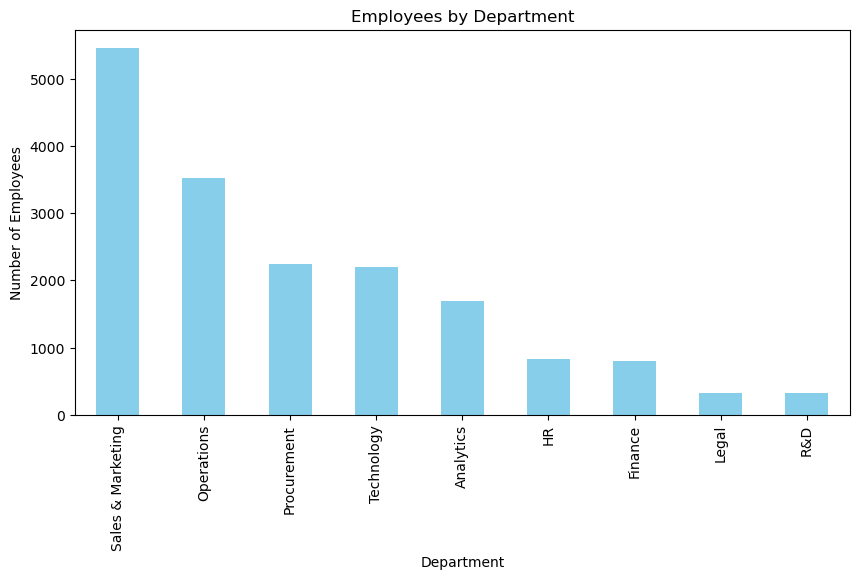

In [13]:
## Department Distribution
plt.figure(figsize=(10,5))

employee['department'].value_counts().plot(kind='bar',color='skyblue')

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

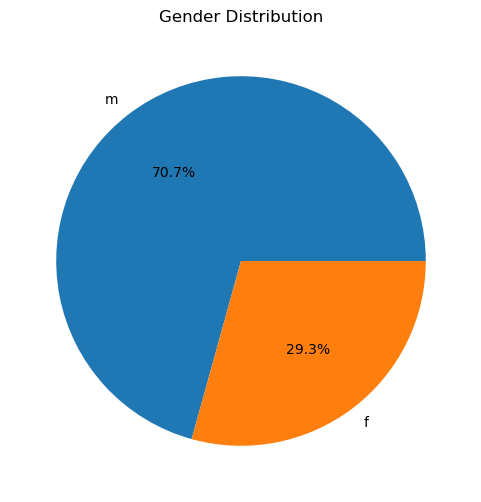

In [14]:
## Gender Distribution
plt.figure(figsize=(6,6))

employee['gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

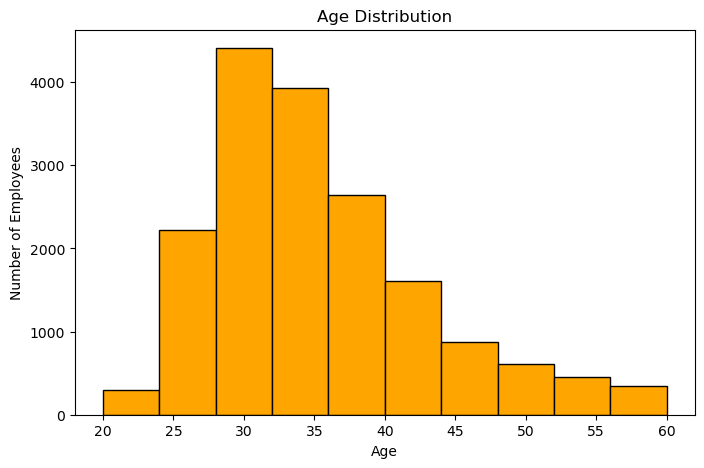

In [15]:
## Age Distribution
plt.figure(figsize=(8,5))

plt.hist(employee['age'],bins=10,color='orange',edgecolor='black')

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Employees")

plt.show()

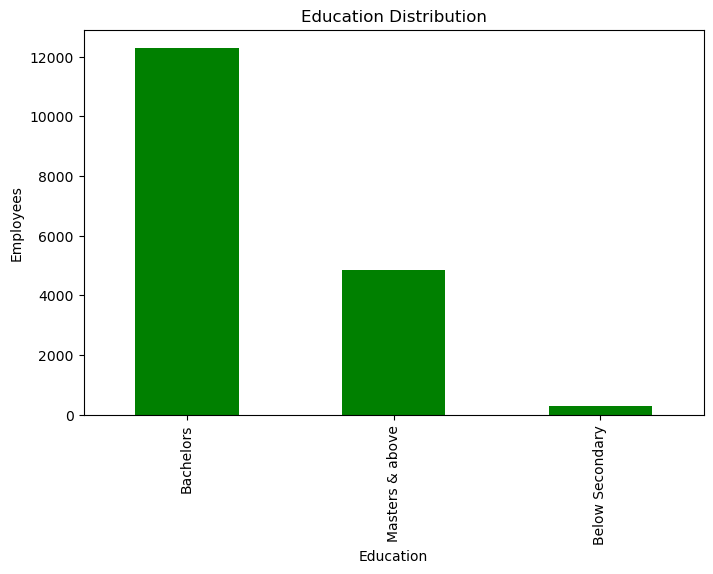

In [16]:
## Education Distribution
plt.figure(figsize=(8,5))

employee['education'].value_counts().plot(kind='bar',color='green')

plt.title("Education Distribution")

plt.xlabel("Education")

plt.ylabel("Employees")

plt.show()

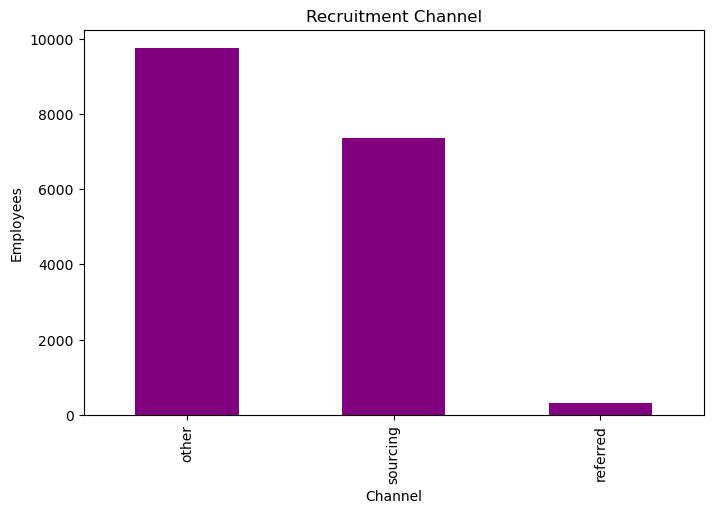

In [17]:
## Recruitment Channel
plt.figure(figsize=(8,5))

employee['recruitment_channel'].value_counts().plot(kind='bar',color='purple')

plt.title("Recruitment Channel")

plt.xlabel("Channel")

plt.ylabel("Employees")

plt.show()

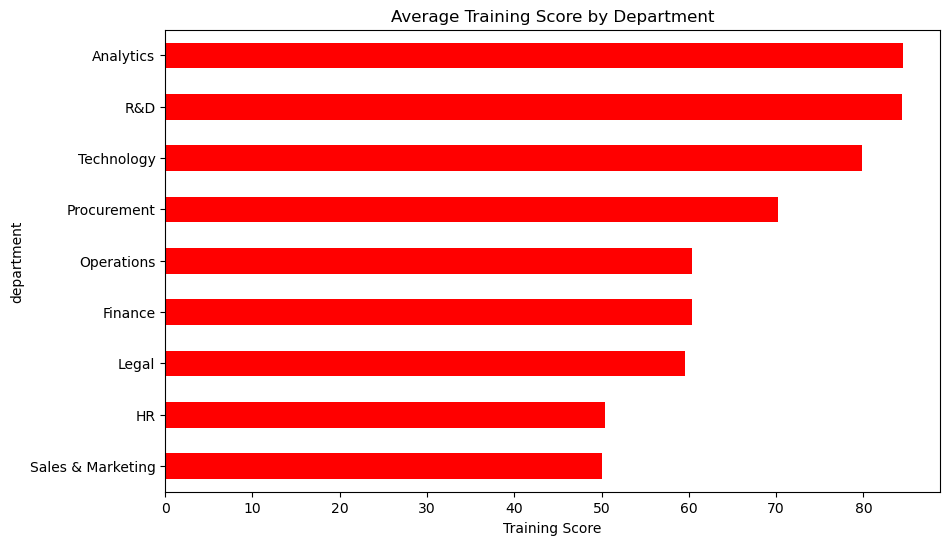

In [18]:
## Average Training Score by Department
employee.groupby('department')['avg_training_score'].mean().sort_values().plot(kind='barh',figsize=(10,6),color='red')

plt.title("Average Training Score by Department")

plt.xlabel("Training Score")

plt.show()

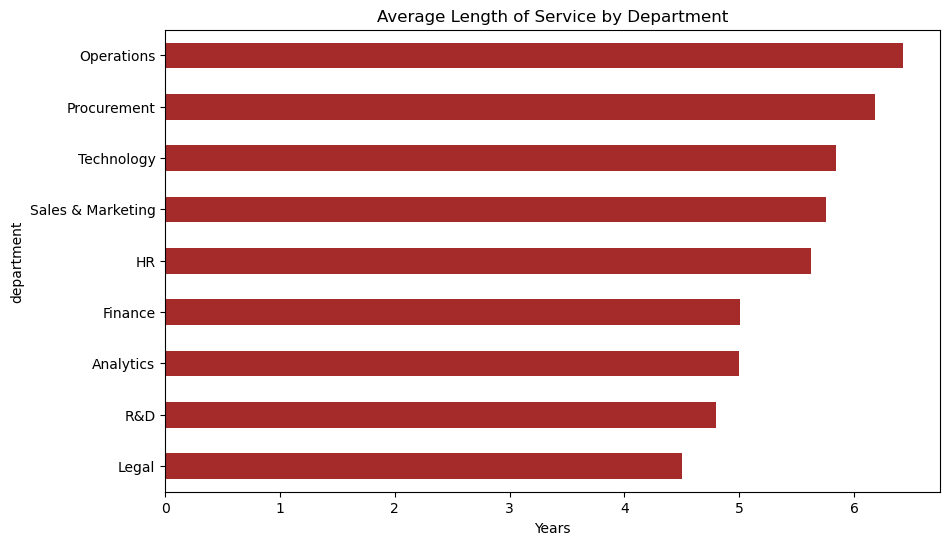

In [19]:
## Average Length of Service
employee.groupby('department')['length_of_service'].mean().sort_values().plot(kind='barh',figsize=(10,6),color='brown')

plt.title("Average Length of Service by Department")

plt.xlabel("Years")

plt.show()


In [20]:
## KPI Analysis
employee['KPIs_met_more_than_80'].value_counts()

KPIs_met_more_than_80
0    11165
1     6250
Name: count, dtype: int64

In [21]:
## Awards Analysis
employee['awards_won'].value_counts()

awards_won
0    17008
1      407
Name: count, dtype: int64

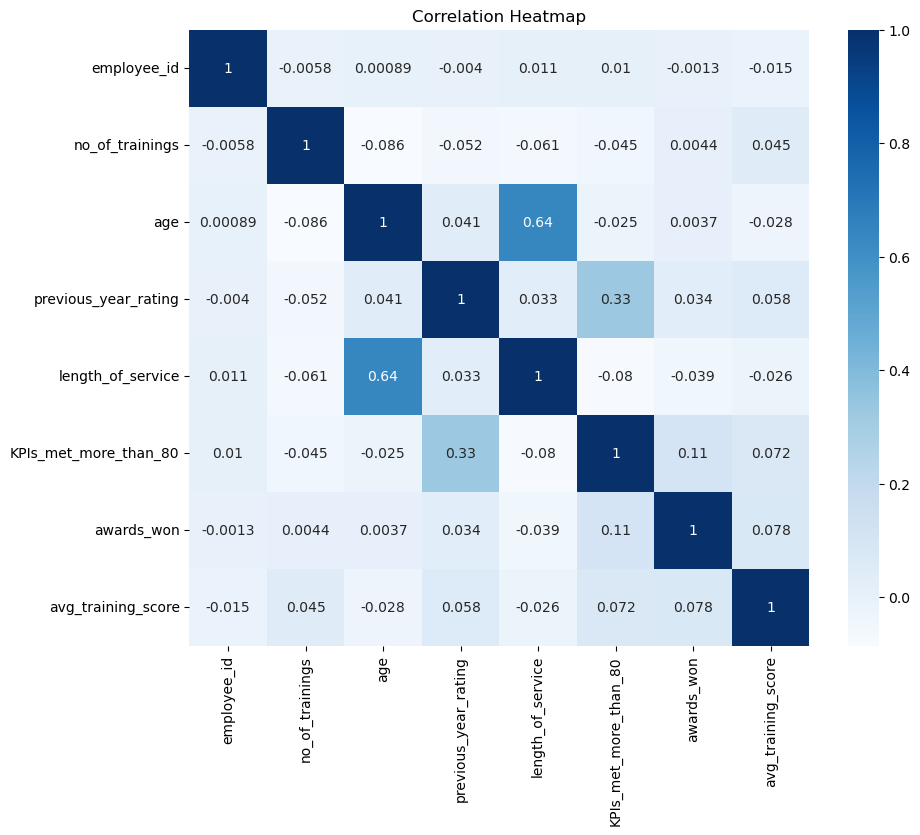

In [22]:
## Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(employee.corr(numeric_only=True),annot=True,cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

In [23]:
## Average Age
print("Average Age:",employee['age'].mean())

Average Age: 34.807981625035886


In [24]:
## Average Training Score
print("Average Training Score:",employee['avg_training_score'].mean())

Average Training Score: 63.17772035601493


In [25]:
## Average Length of Service
print("Average Length of Service:",employee['length_of_service'].mean())

Average Length of Service: 5.8014929658340515


In [26]:
## Average Previous Rating
print("Average Previous Year Rating:",employee['previous_year_rating'].mean())

Average Previous Year Rating: 3.318690783807063


In [28]:
## Recommendations

## 1. Improve training programs in departments with lower training scores.

## 2. Reward employees who consistently meet KPI targets.

## 3. Increase employee engagement in departments with lower average length of service.

## 4. Recognize high-performing employees through awards and promotions.

## 5. Strengthen recruitment strategies to attract skilled candidates.

## 6. Monitor employee performance regularly using KPI and training scores.